# Time-frequency mean-centred analysis

This tutorial shows the visualization options for time-frequency analysis.

## Loading data

First we will load the raw data and extract epochs.

In [2]:
import numpy as np
import mne
from mne.datasets import sample
from mne.stats import permutation_cluster_test

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
raw_fname = meg_path / "sample_audvis_filt-0-40_raw.fif"

raw = mne.io.read_raw_fif(raw_fname)
events = mne.find_events(raw, stim_channel="STI 014")

# Extract epochs
epochs = mne.Epochs(
    raw,
    events,
    event_id={
        "aud/l": 1,
        "aud/r": 2,
        "vis/l": 3,
        "vis/r": 4
    },
    tmin=-1, tmax=2,
    picks=['eeg'],
    baseline=(None, 0),
    preload=True,
    verbose=False
)
epochs = epochs.resample(100)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


## Running time-frequency decomposition

Next, we will perform a time-frequency decomposition via Morlet wavelets.

In [3]:
tfr = epochs.compute_tfr(
    method="morlet",
    freqs=np.exp(np.linspace(np.log(3), np.log(30), 20)), # log space freqs
    n_cycles=5,
    decim=5,
    return_itc=False,
    average=False)
tfr = tfr.crop(tmin=-0.2, tmax=0.8)
# Baseline correction: log-transform, then subtract baseline mean
tfr.data = 10*np.log10(tfr.data)
tfr = tfr.apply_baseline(mode="mean", baseline=(None, 0))

Applying baseline correction (mode: mean)


## Fitting and evaluating mean-centred PLS model

Next, we will fit a mean-centred PLS model comparing the auditory vs visual trials.

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>,
        <Axes: ylabel='Brain score'>], dtype=object))

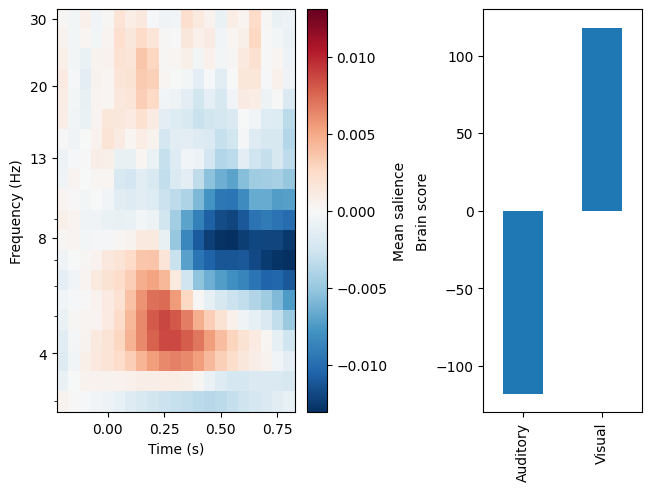

In [4]:
import mne_plsc
import pandas as pd

labels = mne_plsc.utils.get_epoch_labels(tfr)
# Collapse left vs right
mapping = {'aud/l': 'Auditory',
           'aud/r': 'Auditory',
           'vis/l': 'Visual',
           'vis/r': 'Visual'}
labels = [mapping[lab] for lab in labels]
res = mne_plsc.fit_mc(tfr,
                      between=labels,
                      random_state=123)
res.plot_lv(0)

In the plot above, the left panel shows a pattern of brain saliences over times, frequencies, and channels. It appears to represent increased theta power and reduced alpha power, but we don't yet know about its spatial distribution because the saliences are averaged over channels. The right panel shows us that this pattern is more strongly expressed in response to visual than auditory stimuli. We can assess the significance of this pattern via permutation testing. We will do 100 permutations here for speed, but it would be advisable to do many more for a real analysis.

In [5]:
res.permute(100)
print(res.summary())

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 19.82it/s]

   LV index  singular value  variance explained   p value
0         0       166.90936                 1.0  0.009901
1         1         0.00000                 0.0       NaN


## Cluster analysis

If we want to know where on the scalp theta power increases and alpha power decreases, we need to examine the clusters of strong saliences. To do so, we will first perform bootstrap resampling to estimate the $z$ scores of the brain saliences. For speed, we will only perform 100 bootstrap resamples, but for a real analysis we would do many more.

In [6]:
res.bootstrap(100)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:10<00:00,  9.43it/s]


Before cluster analysis, it is necessary to add an adjacency matrix to the data, indicating which channels and times can be part of the same cluster. After adding one, we can find clusters where the absolute $z$ values are above some threshold.

In [7]:
res.add_adjacency()
res.cluster(threshold=4)

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 59
Clustering z-scores
Computing clusters for lv_idx 0...
32 clusters


This yields many clusters, but as we can see, there are only two clusters that account for more than 10% of the saliences that are above our threshold:

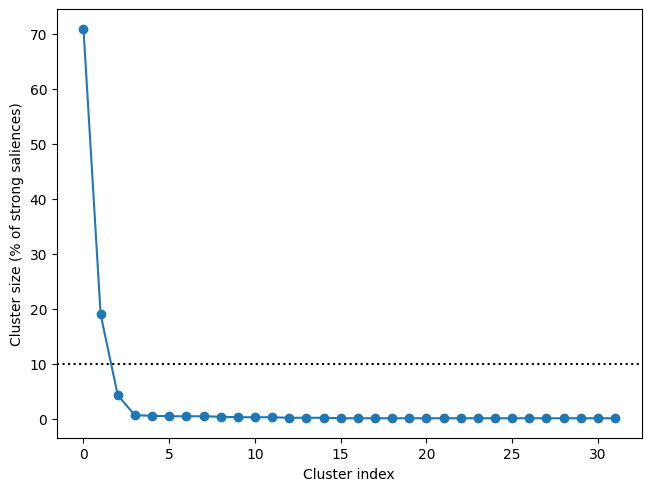

In [8]:
f, ax = res.plot_cluster_sizes(lv_idx=0)
ax.axhline(y=10, c='k', ls=':') # Show 10% line

Plotting these clusters shows us that they correspond to the frequency bands we visually identified earlier, and shows us that are most strongly represented over occipital sites:

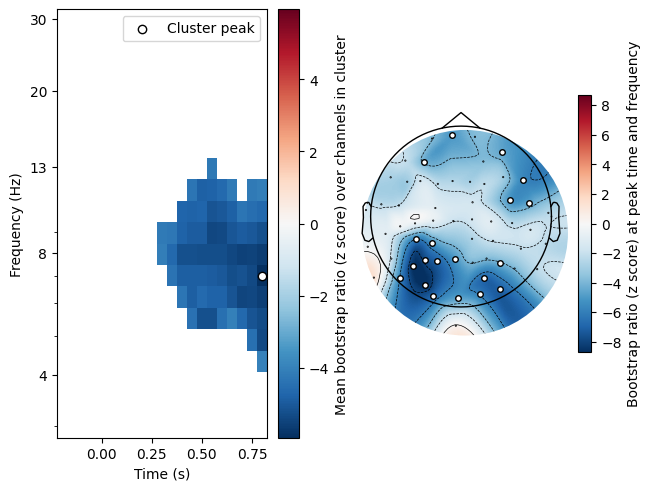

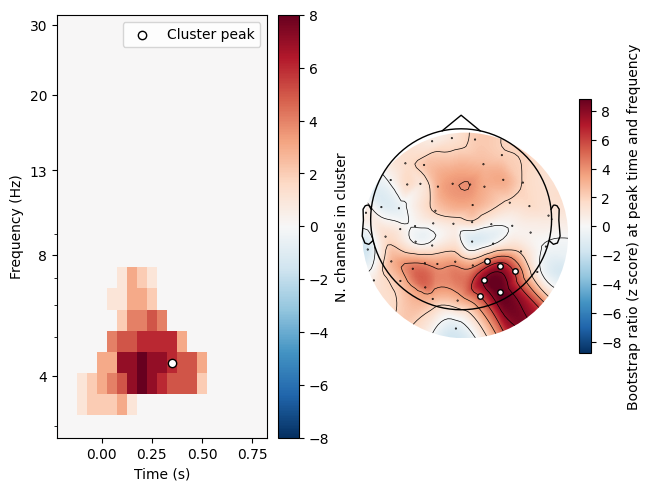

In [9]:
res.plot_cluster(lv_idx=0, cluster_idx=0)
res.plot_cluster(lv_idx=0, cluster_idx=1, plot_type='distribution')

For further analysis, we can extract the actual spectral power data in these clusters. Since we baseline corrected the spectral data before fitting the model, we can see how theta and alpha power differ from baseline in each condition:

alpha         Axes(0.1,0.15;0.363636x0.75)
theta    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

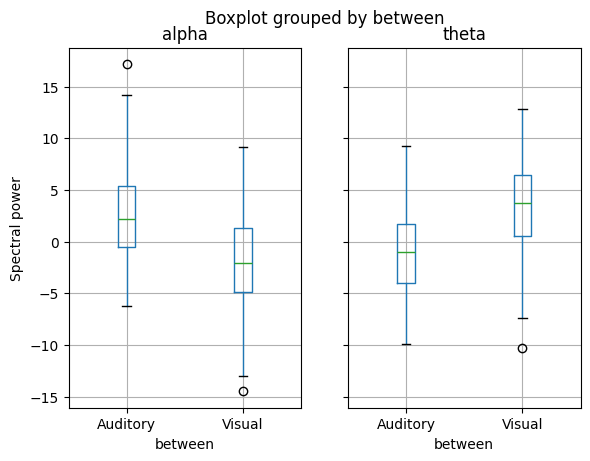

In [10]:
df = res.get_cluster_data(lv_idx=0, cluster_idx=[0, 1])
df['cluster_idx'] = df['cluster_idx'].replace({0: 'alpha', 1: 'theta'})
df.groupby('cluster_idx').boxplot(column='cluster_mean', by='between',
                                  ylabel='Spectral power')